# Diagnostic tests on the return series

In the following notebook, I examine the return data, on which both the GARCH(1,1) and my deep learning hybrid GARCH model are trained. This analysis is part of the postmortem on my model, showing that the statistical insignificance of both models stems from the structure of the training data.

Using visual evidence, the Ljung-Box test, and the ARCH-LM test, I find no ARCH effects, meaning that there was no volatility clustering, which explains the behavior of both the GARCH and hybrid models. 

---

## Volatility Clustering and Autocorrelation
The main question that is answered here is whether the data underlying my thesis actually exhibits any detectable volatility clustering. 

**Volatility clustering** is a stylized fact of return, which states that periods of high volatility, a jump in return, are followed by more volatility, or in other words, whether the market has memory. If there is volatility clustering, such as calm periods being followed by calm periods and turbulent periods followed by turbulent periods, then models, such as the GARCH, can be used to predict how volatility behaves. Conversely, if there is no volatility clustering, then neither my deep learning hybrid nor a standard econometric GARCH yield statistical significance. We also say **ARCH effects** to refer to volatility clustering

**Autocorrelation** means a series is correlated with its own past. In non-technical terms, that means that if a high value today is followed by a high return tomorrow, there is positive autocorrelation of lag 1. Lag 2 means we look at whether today's value is related to the value of two periods later and so on. We use squared returns as a proxy for volatility, as squaring the return series removes the sign. That way, a large negative return followed by a large positive return is regarded as two large moves after each other, which fits volatility clustering.

In [1]:
#Importing data handling
import pandas as pd
import numpy as np

#Importing plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf

#Importing statistical testing (Ljung-Box Test & ARCH-LM Test)
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

In [2]:
#Import only the return series & timestamp from the CSV (which includes all other microstructure inputs) 
file = '../input/data_5min.csv'
df = pd.read_csv(file, sep=';', usecols=['window_end (UTC)', 'return_basis_points'])
print(f"Loaded {len(df)} observations")

#Remove all NULL values, similar to how it was handled in the thesis
df_clean = df.dropna(subset=['return_basis_points'])
print(f"Loaded {len(df_clean)} non-NA observations") 

print("The following is a description of the cleaned data:")
df_clean.describe()

Loaded 2942 observations
Loaded 2919 non-NA observations
The following is a description of the cleaned data:


,return_basis_points
count,2919.000000
mean,-0.000279
std,0.063527
min,-1.172134
25%,-0.001000
50%,0.000000
75%,0.000200
max,2.120971


## Visual evidence against volatility clustering 
First, I visualize the return and squared return series. If there is volatility clustering, we would see large spikes in the return series followed by large spikes in any direction. Simpler, in the squared return series, we would see large spikes followed by large spikes.

Here, I use the non-cleaned data `df`, which includes the 23 gaps in data to also show the breaks in data collection.

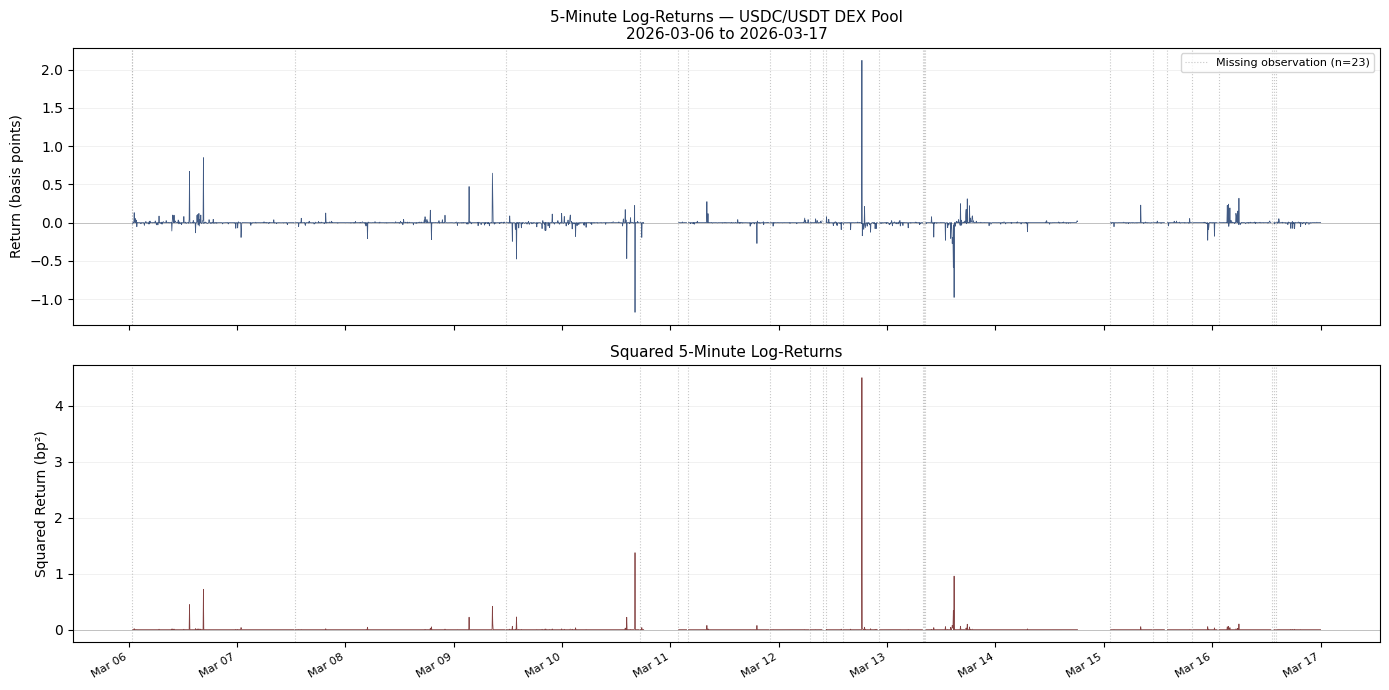

In [3]:
#Load data
returns = df['return_basis_points'].values
timestamps = pd.to_datetime(df['window_end (UTC)']).values
squared_returns = returns**2

gap_mask = np.isnan(returns) #Converts return values into True/False depending on if value is NaN (True if NaN)
gap_ts   = timestamps[gap_mask] #Extracts timestamps, if return is NaN

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True) #Two plots one under the other

#-------------Top plot: returns-----------------
ax1.plot(timestamps, returns,
        color="#1f3d6e", linewidth=0.55, alpha=0.85, zorder=3) #Plots return series
for gt in gap_ts:
    ax1.axvline(gt, color="#b0b0b0", linewidth=0.8,
               linestyle=":", alpha=0.7, zorder=2) #For each gap in the series, plot a gray, dotted line
    
ax1.axvline(gap_ts[0], color="#b0b0b0", linewidth=0.8, linestyle=":",
            alpha=0.7, label=f"Missing observation (n={gap_mask.sum()})", zorder=2) #Re-draw first observation to add label

ax1.axhline(0, color="black", linewidth=0.4, alpha=0.4, zorder=1)
ax1.set_ylabel("Return (basis points)", fontsize=10)
ax1.set_title("5-Minute Log-Returns — USDC/USDT DEX Pool\n2026-03-06 to 2026-03-17", fontsize=11)
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(axis="y", alpha=0.25, linewidth=0.5)

#-------------Bottom plot: squared returns, proxy for volatility-----------------
ax2.plot(timestamps, squared_returns,
         color="#6e1f1f", linewidth=0.55, alpha=0.85, zorder=3) #Plots squared return series

for gt in gap_ts:
    ax2.axvline(gt, color="#b0b0b0", linewidth=0.8, linestyle=":", alpha=0.7, zorder=2) #Adds gap markers, no need for extra one, because already above

ax2.axhline(0, color="black", linewidth=0.4, alpha=0.4, zorder=1)
ax2.set_ylabel("Squared Return (bp²)", fontsize=10)
ax2.set_title("Squared 5-Minute Log-Returns", fontsize=11)
ax2.grid(axis="y", alpha=0.25, linewidth=0.5)

#Shared x-Axis
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.xticks(rotation=30, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

We see that there is 

> no visible clustering in both the return and squared return data. 

Instead spikes are isolated and randomly distributed, behaving more like white noise. There are no periods of persistent volatility.

---

## Ljung-Box test
Aside from visual evidence, I also want to run statistical tests on the squared return series to examine whether the series exhibits any autocorrelation. 
The **Ljung-Box test** (1978) is widely used to test a series for autocorrelation at many lags in finite samples. There are two ways of running this test. The detailed way is to start by calculating the autocorrelations of lag $k$ as $$\rho_k = \frac{\sum^T_{t=k+1}(r_t^2 - \bar{r^2})(r_{t-k}^2 - \bar{r^2})}{\sum^T_{t=k+1}(r^2_t - \bar{r^2})},$$ where $\bar{r^2}$ is the mean, for lags 1 through 10, then calculate the test statistic $$Q(10) = T(T+2) \sum_{k=1}^{10} \frac{\rho_k^2}{T-k},$$ where $T = 2919$ is the number of observations, and compare it to the $\chi^2$ distribution with 10 degrees of freedom. The easier way is to run the statsmodel package's `acorr_ljungbox` function. For the sake of readability, I chose the second option.

In [4]:
#Ljung-Box test
cleaned_squared_returns = df_clean['return_basis_points'].values**2
lb = acorr_ljungbox(cleaned_squared_returns, lags = 10, return_df=True) #10 lag Ljung-Box test, returning a pandas dataframe
lb.round(4) #Rounding it to four decimal places for better readability

,lb_stat,lb_pvalue
1,0.2477,0.6187
2,0.7617,0.6833
3,0.7702,0.8566
4,0.7773,0.9415
5,0.7967,0.9772
6,0.8005,0.9921
7,0.9583,0.9955
8,0.9660,0.9985
9,0.9678,0.9995
10,0.9759,0.9998


The null hypothesis: *there is no autocorrelation in the square return series*, 

> clearly cannot be rejected at any reasonable (and unreasonable) level, as p-values are near 1. 

The test clearly shows that there are no ARCH effects and the return data is indistinguishable from white noise.

---

Below is a plot of the autocorrelation functions for 40 lags, similar to the one in the thesis paper, again clearly showing that at all lags, no autocorrelation can be found, as they all lie inside the 95% confidence interval for the null hypothesis.

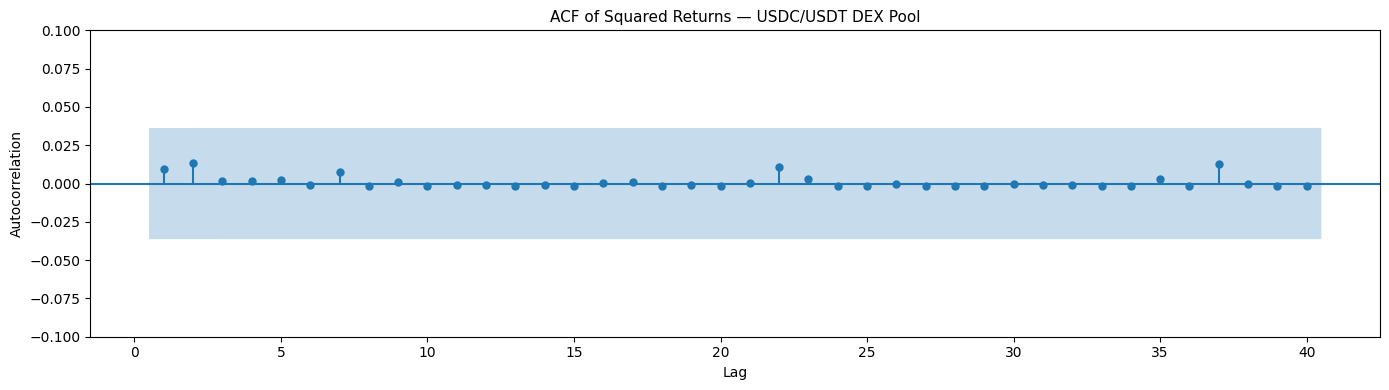

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(cleaned_squared_returns, lags=40, ax=ax, zero=False) #plot the ACFs of 40 lags, remove 0 lag for visibility

ax.set_title("ACF of Squared Returns — USDC/USDT DEX Pool", fontsize=11)
ax.set_xlabel("Lag", fontsize=10)
ax.set_ylabel("Autocorrelation", fontsize=10)
ax.set_ylim(-0.1, 0.1)

plt.tight_layout()
plt.show()

## ARCH-LM test
Lastly, I want to run another statistical test, the **ARCH-LM test**, to check for volatility clustering. The approach is slightly different from the Ljung-Box test, which checks if all autocorrelations are jointly equal to zero. Instead I essentially run a regression of squared returns on their own lagged values: $$r_t^2 = \alpha_0 + \alpha_1 r^2_{t-1} + \alpha_2 r^2_{t-2} + ... + \alpha_m r^2_{t-m} + \epsilon_t.$$ 
If no ARCH effects exist, the regression should have near zero $R^2$, indicating that lagged square returns have no predictive power, resulting in a high p-value. Mathematically, I compare the statistic $LM = T \cdot R^2$, where T is the number of observations, to the $\chi^2$ distribution with m degrees of freedom.

In [6]:
lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(cleaned_squared_returns, nlags=10) #Function needs to output 4 values, even though I do not show them
print(f"ARCH-LM statistic : {lm_stat:.4f}")
print(f"ARCH-LM p-value : {lm_pvalue:.18f}")

ARCH-LM statistic : 0.0060
ARCH-LM p-value : 0.999999999999998002


Again, the test shows that there is 

> no volatility clustering to be observed. 

The LM statistic is 0.006 with a p-value of essentially 1, as far above any significance level as possible.

---

| Test | Statistic | p-value | Conclusion |
|------|-----------|---------|------------|
| Ljung-Box (lag 10) | 0.976 | 0.9998 | Fail to reject |
| ARCH-LM (lag 10) | 0.006 | ~1 | Fail to reject |

Ultimately, this demonstrates that given the collected data, both my deep learning hybrid GARCH and the GARCH(1,1) benchmark I used for comparison cannot learn anything useful. 

The GARCH is a model specifically designed to model volatility clustering, of which there is none. The loss surface is flat and featureless; any parameter combination (used to estimate GARCH with maximum likelihood, meaning the parameters that best fit the data) would produce a similar likelihood, so the model has nothing to learn.